In [108]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

from scipy.stats import kruskal, mannwhitneyu

In [109]:
df = pd.read_excel("emdat-country-profiles_2026_06_06.xlsx")

df = df.drop(index=0).reset_index(drop=True)
df.head()

,Year,Country,ISO,Disaster Group,Disaster Subroup,Disaster Type,Disaster Subtype,Total Events,Total Affected,Total Deaths,"Total Damage (USD, original)","Total Damage (USD, adjusted)",CPI
0,2000,Afghanistan,AFG,Natural,Climatological,Drought,Drought,1,2580000,37,50000.0,93479,53.487737
1,2000,Algeria,DZA,Natural,Hydrological,Flood,Flash flood,1,100,28,NaN,NaN,53.487737
2,2000,Angola,AGO,Natural,Hydrological,Flood,Flood (General),3,9011,15,NaN,NaN,53.487737
3,2000,Angola,AGO,Natural,Hydrological,Flood,Riverine flood,1,70000,31,10000000.0,18695874,53.487737
4,2000,Angola,AGO,Natural,Hydrological,Mass movement (wet),Landslide (wet),1,NaN,13,NaN,NaN,53.487737


In [110]:
df.columns

Index(['Year', 'Country', 'ISO', 'Disaster Group', 'Disaster Subroup',
       'Disaster Type', 'Disaster Subtype', 'Total Events', 'Total Affected',
       'Total Deaths', 'Total Damage (USD, original)',
       'Total Damage (USD, adjusted)', 'CPI'],
      dtype='str')

In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6507 entries, 0 to 6506
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          6507 non-null   object 
 1   Country                       6507 non-null   str    
 2   ISO                           6507 non-null   str    
 3   Disaster Group                6507 non-null   str    
 4   Disaster Subroup              6507 non-null   str    
 5   Disaster Type                 6507 non-null   str    
 6   Disaster Subtype              6507 non-null   str    
 7   Total Events                  6507 non-null   object 
 8   Total Affected                5280 non-null   object 
 9   Total Deaths                  4648 non-null   object 
 10  Total Damage (USD, original)  2213 non-null   float64
 11  Total Damage (USD, adjusted)  2200 non-null   object 
 12  CPI                           6430 non-null   float64
dtypes: float64(2),

In [112]:
df.describe()

,"Total Damage (USD, original)",CPI
count,2.213000e+03,6430.000000
mean,1.753654e+09,72.690106
std,8.716576e+09,13.262874
min,2.000000e+03,53.487737
25%,2.050000e+07,62.617195
50%,1.400000e+08,71.315088
75%,8.400000e+08,80.390383
max,2.100000e+11,100.000000


In [113]:
cols = ['Year', 'Total Events', 'Total Affected', 'Total Deaths']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

df["Total Damage (USD, adjusted)"] = pd.to_numeric(
    df["Total Damage (USD, adjusted)"], errors='coerce'
).astype('float')

In [114]:

missing = pd.DataFrame({
    "Count": df.isna().sum(),
    "Percentage": (df.isna().sum() / len(df)) * 100
})
missing

,Count,Percentage
Year,0,0.000000
Country,0,0.000000
ISO,0,0.000000
Disaster Group,0,0.000000
Disaster Subroup,0,0.000000
Disaster Type,0,0.000000
Disaster Subtype,0,0.000000
Total Events,0,0.000000
Total Affected,1227,18.856616
Total Deaths,1859,28.569233


<Axes: >

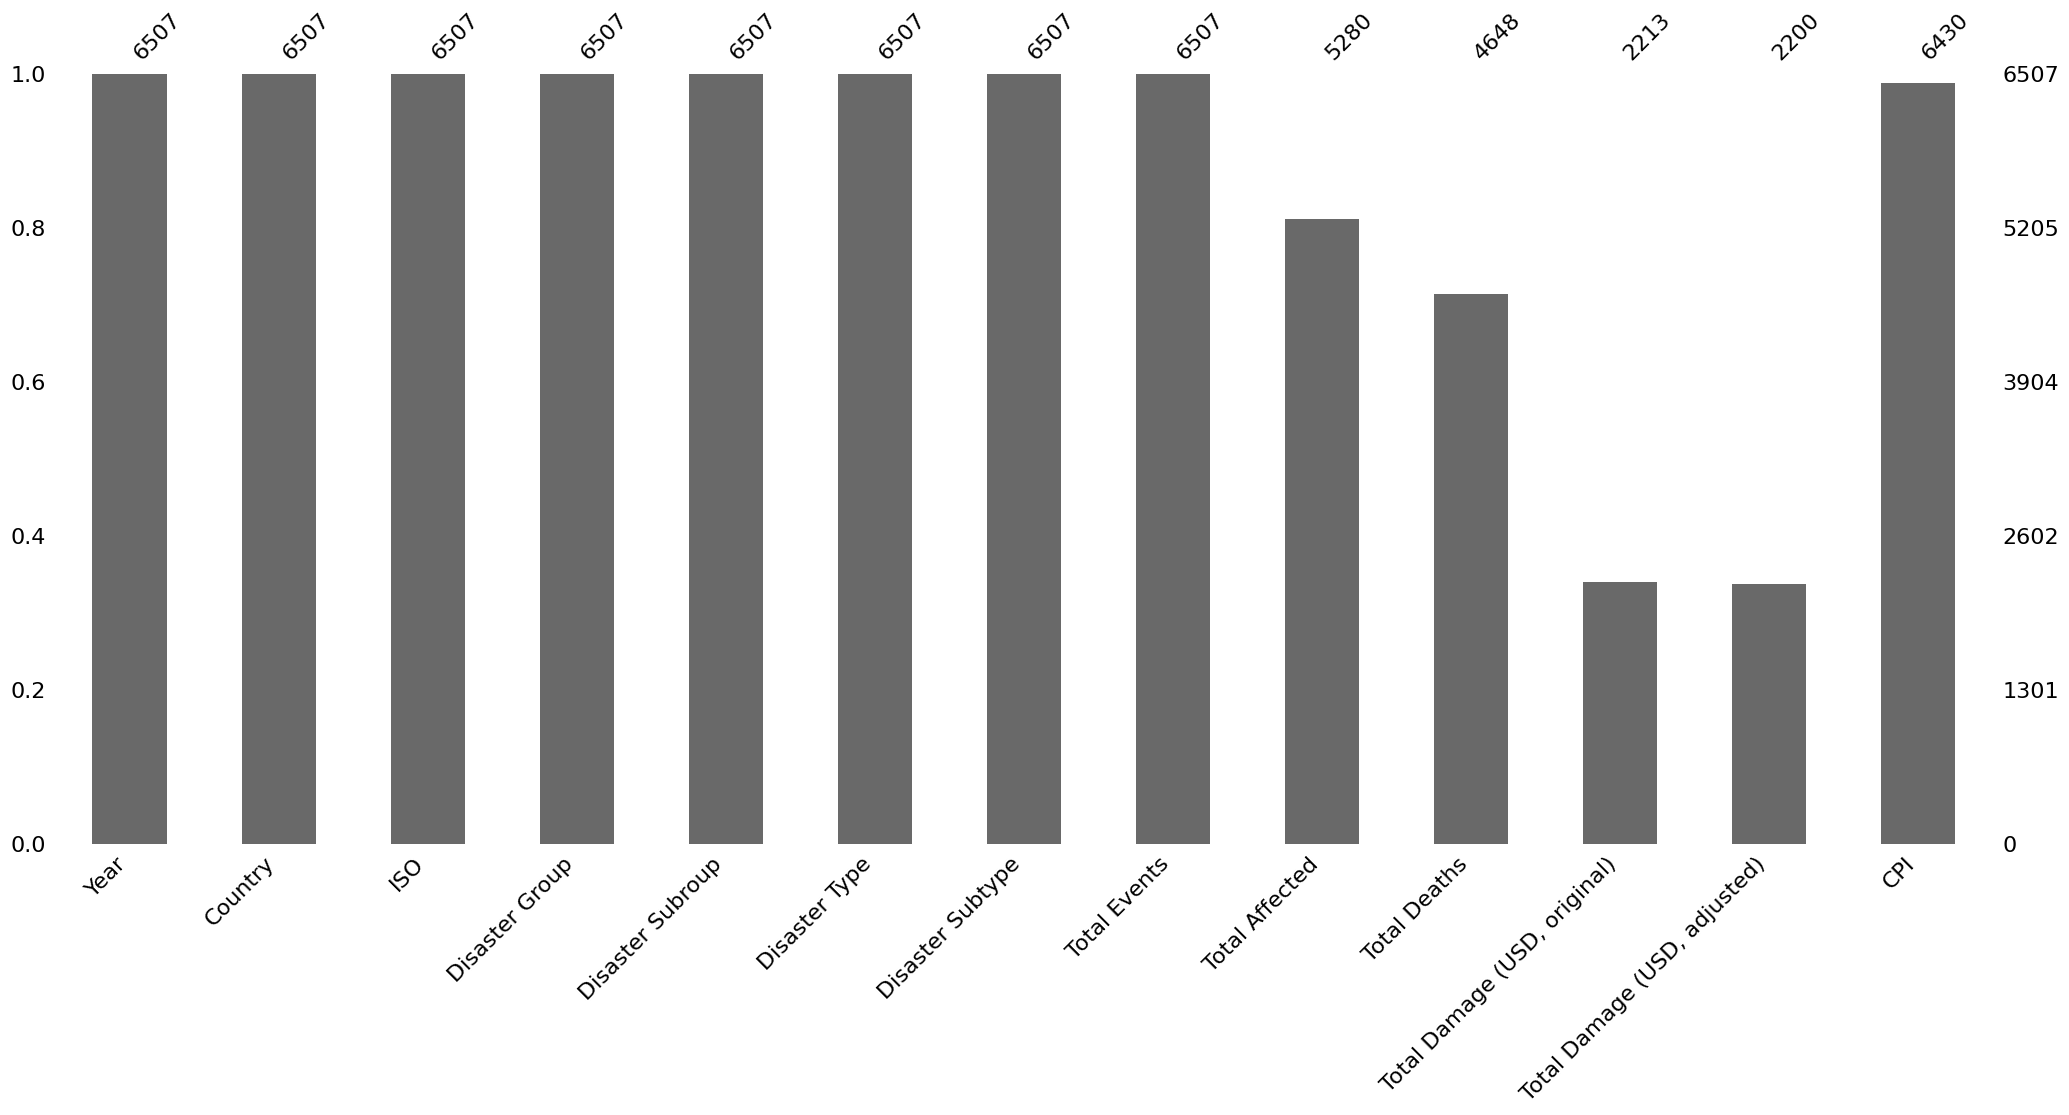

In [115]:
ms.bar(df)

In [116]:
df['death_missing'] = df['Total Deaths'].isna().astype(int)
df['affected_missing'] = df['Total Affected'].isna().astype(int)
df['damage_missing'] = df['Total Damage (USD, original)'].isna().astype(int)

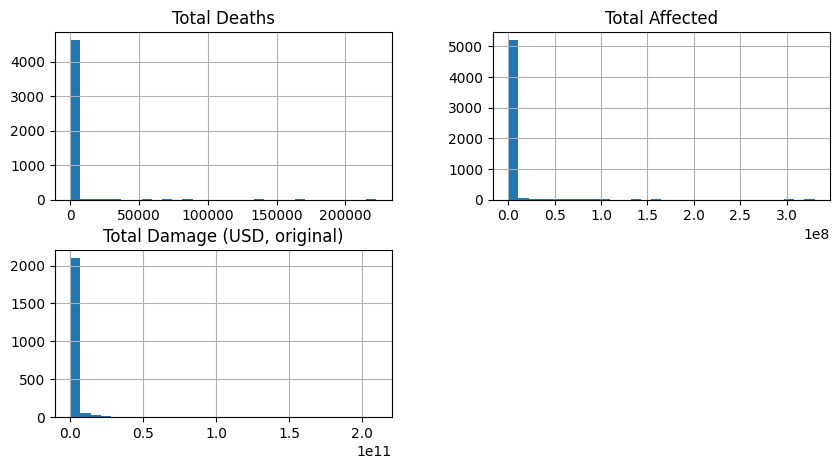

In [117]:
df[['Total Deaths','Total Affected','Total Damage (USD, original)']].hist(bins=30, figsize=(10,5))
plt.show()

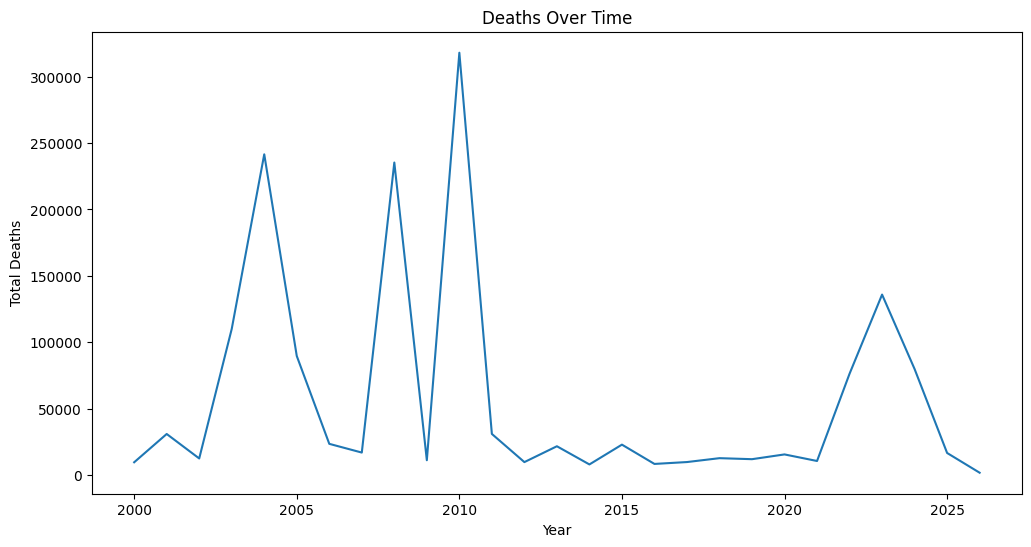

In [118]:
year_wise_impact = df.groupby('Year')['Total Deaths'].sum()

plt.figure(figsize=(12,6))
plt.plot(year_wise_impact.index, year_wise_impact.values)
plt.title('Deaths Over Time')
plt.xlabel('Year')
plt.ylabel('Total Deaths')
plt.show()

In [119]:
df.groupby('Disaster Type')['damage_missing'].mean().sort_values(ascending=False)

Disaster Type
Animal incident                1.000000
Infestation                    0.965517
Mass movement (dry)            0.928571
Extreme temperature            0.912879
Mass movement (wet)            0.864130
Volcanic activity              0.840708
Glacial lake outburst flood    0.714286
Drought                        0.706311
Flood                          0.671555
Wildfire                       0.611940
Storm                          0.539954
Earthquake                     0.498818
Impact                         0.000000
Name: damage_missing, dtype: float64

Economic damage reporting varies substantially by disaster type. Animal incidents, infestations, and extreme temperature events exhibit very high levels of missing damage data (>90%), whereas earthquakes, storms, and floods have comparatively better reporting. This indicates that damage missingness is systematic rather than random and should be accounted for during modeling.

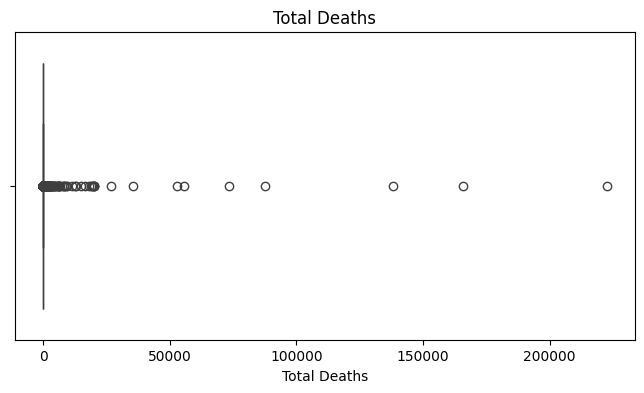

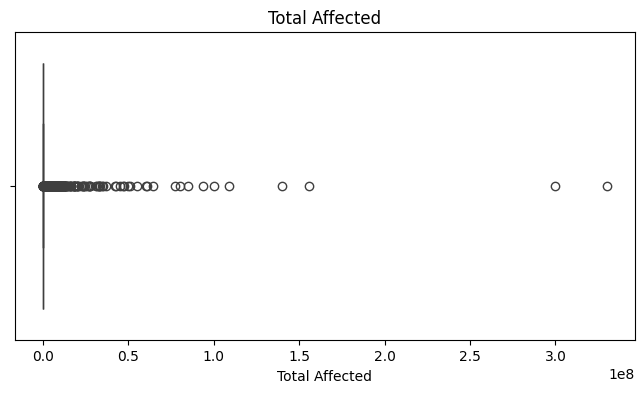

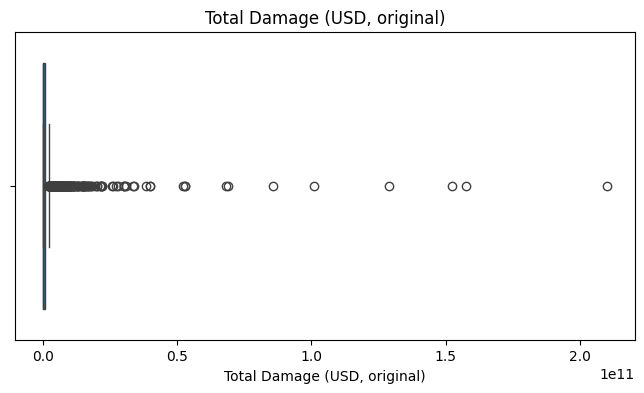

In [120]:
for col in ['Total Deaths','Total Affected','Total Damage (USD, original)']:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

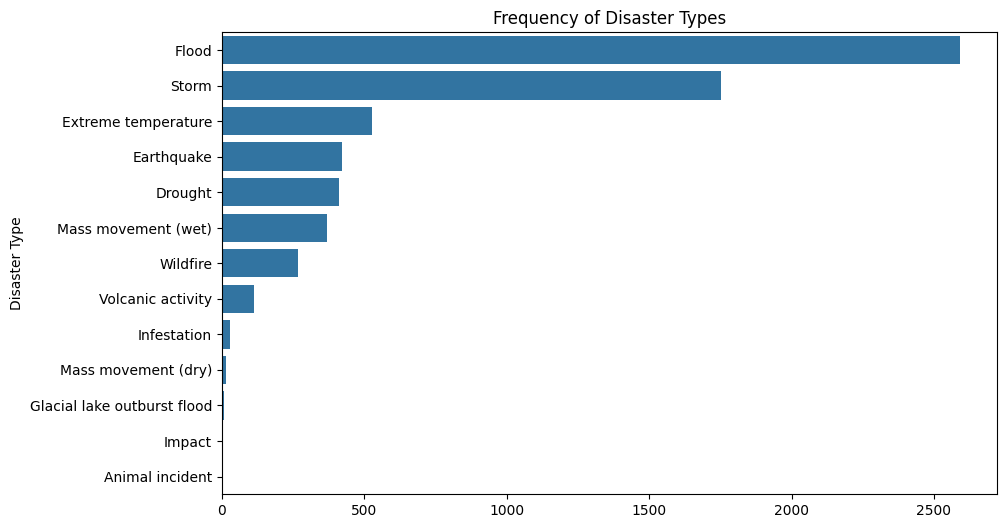

In [121]:
disaster_counts = df['Disaster Type'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=disaster_counts.values, y=disaster_counts.index)
plt.title('Frequency of Disaster Types')
plt.show()

In [122]:
df['Country'].value_counts().head(20)
#this is not also balanced

Country
United States of America    263
China                       225
India                       181
Indonesia                   158
Philippines                 131
Japan                       109
Bangladesh                  107
Pakistan                    107
France                       98
Viet Nam                     96
Mexico                       92
Afghanistan                  90
Australia                    89
Italy                        82
Russian Federation           82
Brazil                       80
Peru                         79
Thailand                     79
Colombia                     78
Argentina                    71
Name: count, dtype: int64

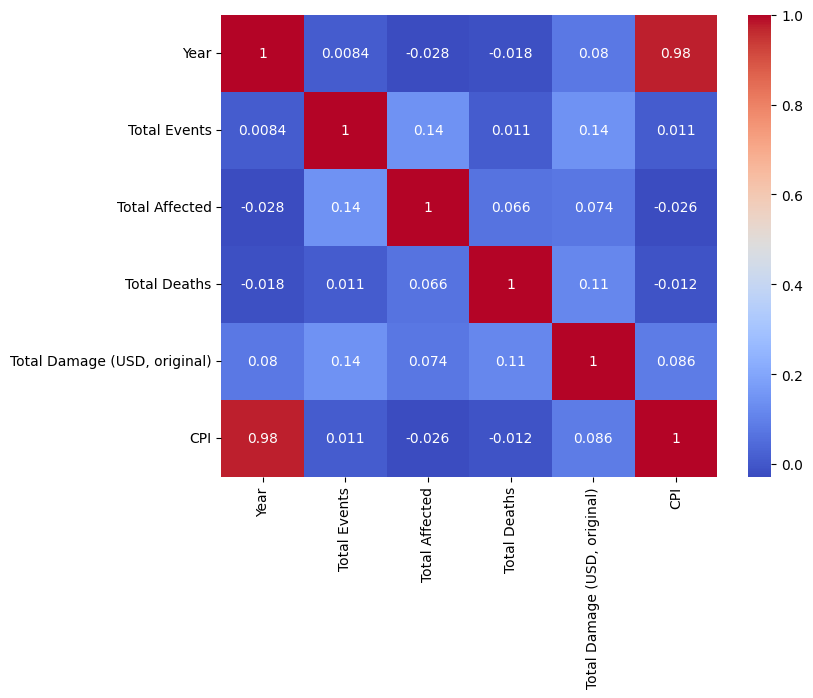

In [123]:
num_cols = [
    'Year',
    'Total Events',
    'Total Affected',
    'Total Deaths',
    'Total Damage (USD, original)',
    'CPI'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Correlation analysis revealed generally weak linear relationships between total deaths and other numerical variables. The strongest relationship observed was between Year and CPI (r = 0.956), reflecting inflation trends over time. Fatalities showed only weak correlations with total events, affected population, and economic damage, suggesting that disaster mortality is influenced more by contextual factors such as disaster type and geographic location than by simple numerical indicators alone.

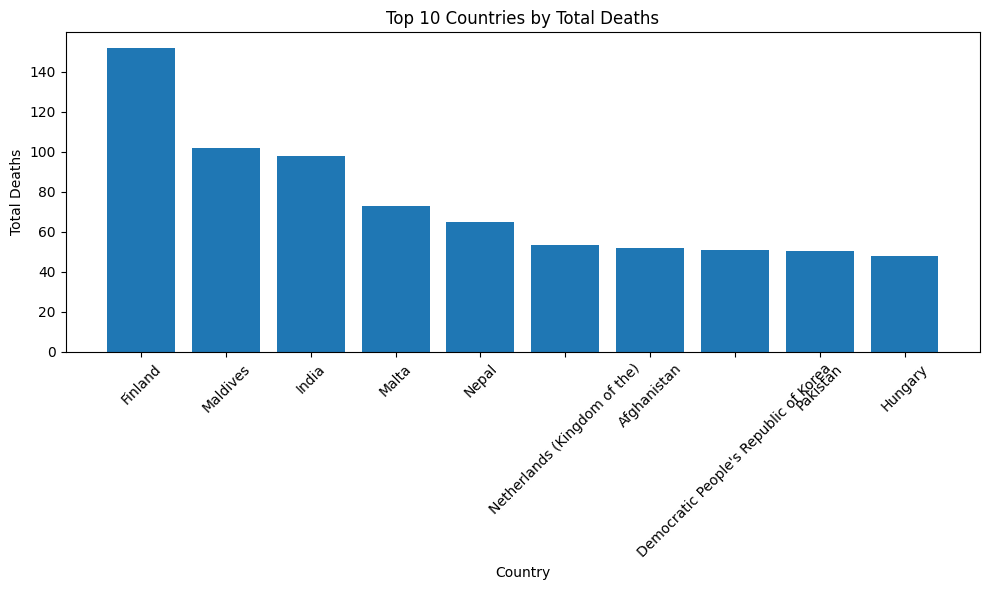

In [124]:
country_wise_impact = (
    df.groupby('Country')['Total Deaths']
      .median() 
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(country_wise_impact.index, country_wise_impact.values)
plt.xlabel('Country')
plt.ylabel('Total Deaths')
plt.title('Top 10 Countries by Total Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# country_wise_impact

Finland, India, Malta, Nepal, and Parkistan recorded the highest cumulative disaster-related deaths in the dataset. This suggests that disaster impacts are not evenly distributed across countries, and geographic location may play a significant role in determining disaster severity and mortality risk.

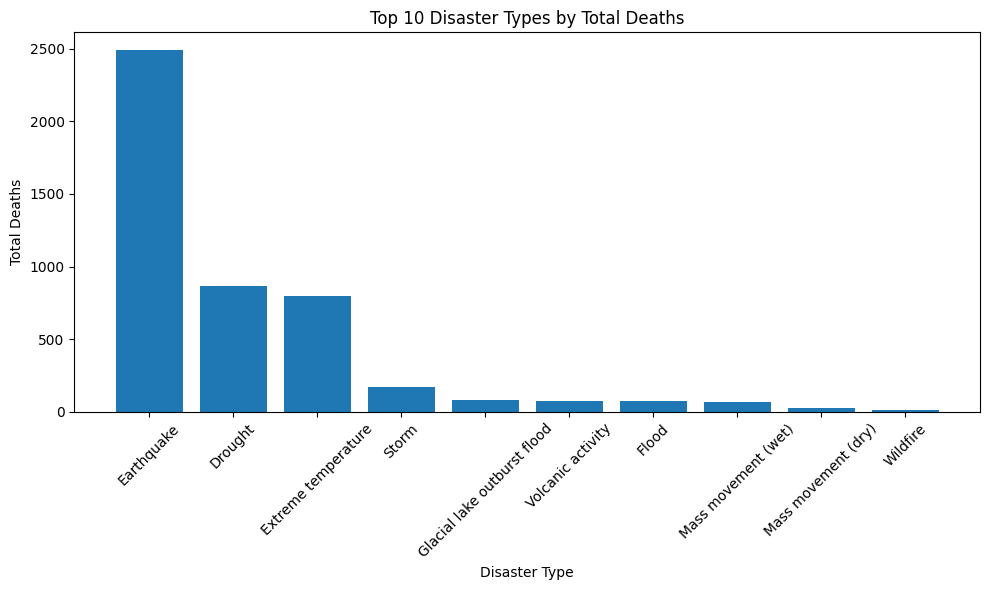

In [125]:
dis_type_wise_impact = (
    df.groupby('Disaster Type')['Total Deaths']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(dis_type_wise_impact.index, dis_type_wise_impact.values)
plt.xlabel('Disaster Type')
plt.ylabel('Total Deaths')
plt.title('Top 10 Disaster Types by Total Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# dis_type_wise_impact

Earthquakes were found to be the deadliest disaster type, with a significantly higher average number of deaths compared to other disaster categories. Extreme temperature events ranked second, while storms, floods, and droughts showed comparatively lower average fatalities. This indicates that disaster type is likely to be an important predictor of mortality in the modeling phase.

For the corr and the above two:- 
The large variation in fatalities across countries and disaster types suggests that categorical features such as Country and Disaster Type may provide stronger predictive power than numerical variables alone when predicting disaster-related deaths.

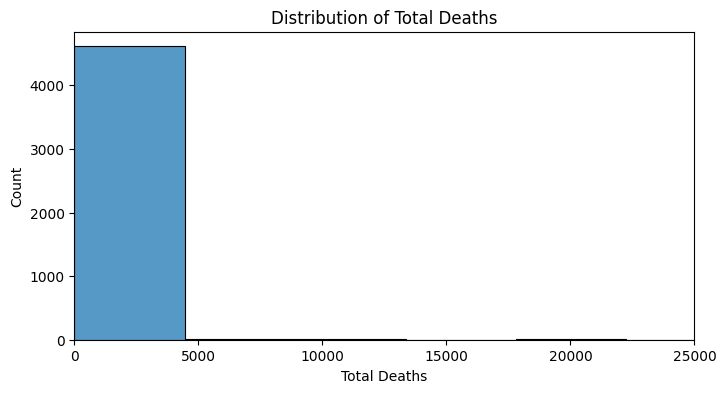

In [126]:
plt.figure(figsize=(8,4))
sns.histplot(df['Total Deaths'], bins=50)

plt.xlim(0, 25000)  # show only 0 to 25,000 on x-axis
plt.title("Distribution of Total Deaths")
plt.show()

The distribution of Total Deaths is highly right-skewed, with most events resulting in low fatalities and a few extreme disasters causing very high death tolls. This creates a strong imbalance in the target variable, which can negatively affect model training.

To address this, a log transformation (log1p) is applied to reduce skewness and compress extreme values, resulting in a more balanced distribution suitable for regression modeling.

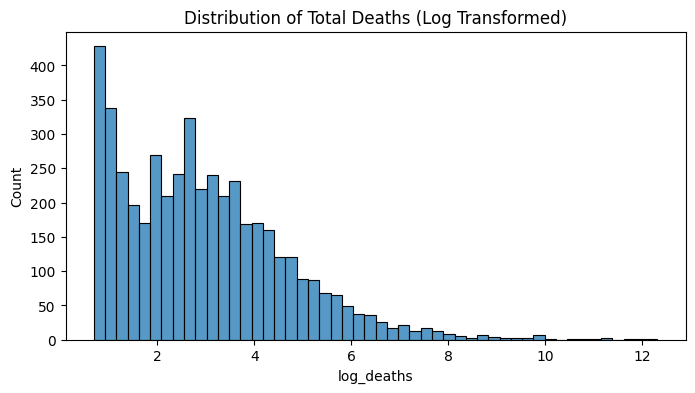

In [127]:
df_model = df.copy()

df_model = df_model[df_model['Total Deaths'].notna()]
df_model['log_deaths'] = np.log1p(df_model['Total Deaths'])

plt.figure(figsize=(8,4))
sns.histplot(df_model['log_deaths'], bins=50)
plt.title("Distribution of Total Deaths (Log Transformed)")
plt.show()

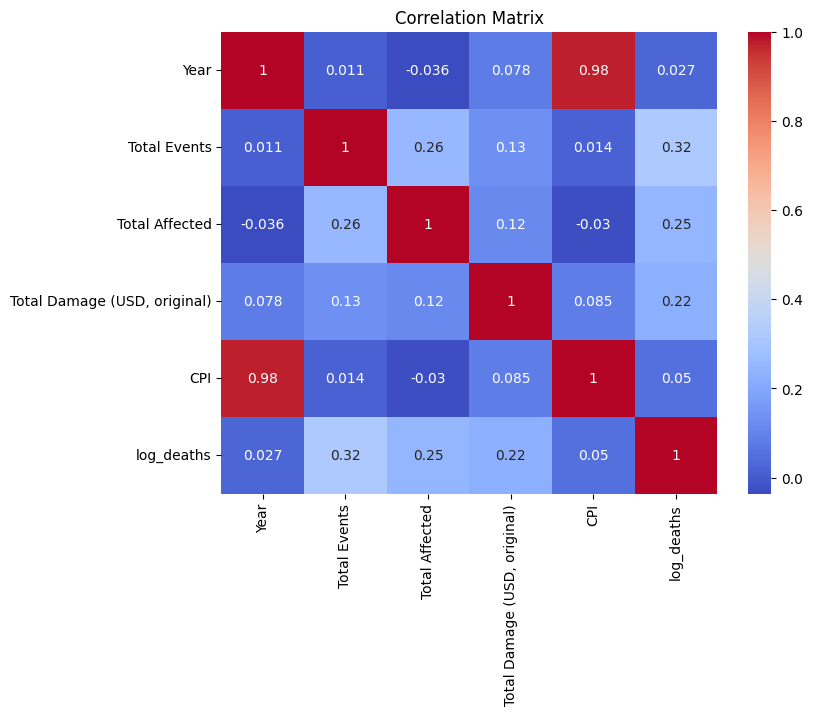

In [128]:
num_cols = [
    'Year',
    'Total Events',
    'Total Affected',
    'Total Damage (USD, original)',
    'CPI',
    'log_deaths'
]

corr = df_model[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Year and CPI are highly correlated (r ≈ 0.95), indicating overlapping temporal information
i did nothing hear for this cause u know tree models walata echchara case ekak na 

### Hypothesis Test 1: Disaster Type affects fatalities

Hypotheses:
* H₀: Mean deaths are the same across all disaster types
* H₁: At least one disaster type has different mean deaths

In [143]:
from scipy.stats import f_oneway

groups = [
    group.dropna().values
    for name, group in df.groupby("Disaster Type")["Total Deaths"]
    if group.dropna().shape[0] > 5   # filter small samples
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 7.77856979190815
p-value: 1.87717168891122e-11


* Since the p-value is extremely small (p < 0.05), we reject the null hypothesis.
* There is statistical evidence suggesting differences in mean fatalities across disaster types, after excluding low-sample categories. This confirms that disaster type is an important factor influencing mortality outcomes.

### Hypothesis Test 2: Country vs fatalities

Hypotheses:
* H₀: No difference in mean deaths between top countries and others
* H₁: There is a difference

In [130]:
from scipy.stats import ttest_ind

top_countries = df[df["Country"].isin(["Haiti", "Indonesia", "China"])]["Total Deaths"]
others = df[~df["Country"].isin(["Haiti", "Indonesia", "China"])]["Total Deaths"]

t_stat, p_value = ttest_ind(top_countries, others, nan_policy='omit')

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 4.354411394669303
p-value: 1.3629625350894607e-05


* Since the p-value is also extremely small (p < 0.05), we reject the null hypothesis.
* The results suggest that geographic location plays a statistically significant role in disaster-related fatalities, with certain countries experiencing systematically higher mortality rates than others.

Both statistical tests confirm that categorical variables such as Disaster Type and Country have a significant relationship with disaster-related fatalities. This supports earlier exploratory findings and reinforces the use of tree-based machine learning models, which are better suited to capture such complex, non-linear relationships.

In [131]:
features = [
    'Year',
    'Country',
    'Disaster Group',
    'Disaster Type',
    'Disaster Subtype',
    'Total Events',
    'CPI',
    'Total Affected',
    'Total Damage (USD, original)'
]

X = df_model[features]
y = df_model['log_deaths']

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [133]:
def group_impute(train, test, col):
    medians = train.groupby('Disaster Type')[col].median()

    train[col] = train.apply(
        lambda r: medians[r['Disaster Type']] if pd.isna(r[col]) else r[col],
        axis=1
    )

    test[col] = test.apply(
        lambda r: medians.get(r['Disaster Type'], train[col].median())
        if pd.isna(r[col]) else r[col],
        axis=1
    )

    return train, test


for col in ['Total Affected', 'Total Damage (USD, original)']:
    X_train, X_test = group_impute(X_train, X_test, col)

In [134]:
cpi_median = X_train['CPI'].median()

X_train['CPI'] = X_train['CPI'].fillna(cpi_median)
X_test['CPI'] = X_test['CPI'].fillna(cpi_median)

In [135]:
for col in ['Country', 'Disaster Group', 'Disaster Type', 'Disaster Subtype']:
    freq = X_train[col].value_counts(normalize=True)

    X_train[col] = X_train[col].map(freq)
    X_test[col] = X_test[col].map(freq).fillna(0)

In [136]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 0.889506496190845
R2: 0.517868536758935


In [137]:
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

In [138]:
for col in X_train_lr.columns:
    X_train_lr[col] = X_train_lr[col].fillna(X_train_lr[col].median())
    X_test_lr[col] = X_test_lr[col].fillna(X_train_lr[col].median())

In [139]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train_lr, y_train)

lin_pred = lin_model.predict(X_test_lr)

In [140]:
lin_mae = mean_absolute_error(y_test, lin_pred)
lin_r2 = r2_score(y_test, lin_pred)

print("Linear Regression MAE:", lin_mae)
print("Linear Regression R2:", lin_r2)

Linear Regression MAE: 1.2186137583365317
Linear Regression R2: 0.13322186339636632


In [141]:
results = pd.DataFrame([
    {"Model": "Linear Regression", "MAE": lin_mae, "R2": lin_r2},
    {"Model": "XGBoost", "MAE": mae, "R2": r2}
])

results.sort_values(by="R2", ascending=False)

,Model,MAE,R2
1,XGBoost,0.889506,0.517869
0,Linear Regression,1.218614,0.133222


The XGBoost model achieved the best performance with an R² score of 0.52 and MAE of 0.89, outperforming the Linear Regression model, which achieved an R² of 0.13 and MAE of 1.22.

This clearly indicates that XGBoost is significantly better at capturing the underlying non-linear relationships in the dataset. The large performance gap between the two models highlights that disaster-related fatalities cannot be effectively modeled using simple linear assumptions.

However, despite the improvement, the R² value of 0.52 suggests that only about half of the variance in disaster fatalities is explained by the available features. This reflects the inherent complexity of disaster impacts, where outcomes are influenced not only by recorded variables such as disaster type, location, and exposure, but also by external factors not present in the dataset, including infrastructure resilience, emergency response capacity, governance, and population density.

Overall, while XGBoost provides a strong improvement over linear regression, the results reinforce that predicting disaster fatalities remains a complex problem with substantial unexplained variability driven by real-world contextual factors.

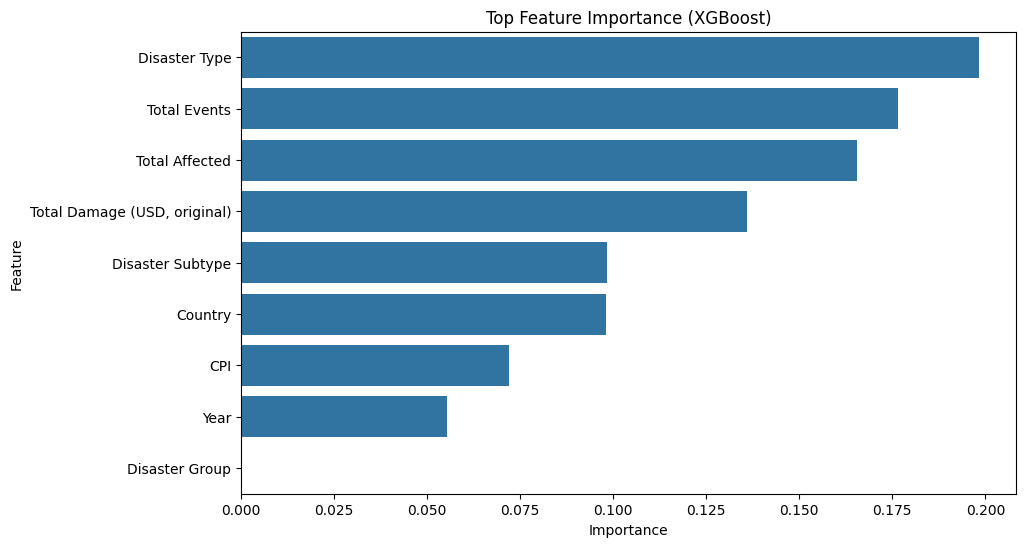

In [142]:
importances = model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(15), x="Importance", y="Feature")
plt.title("Top Feature Importance (XGBoost)")
plt.show()

Feature importance analysis from the XGBoost model shows that disaster subtype and country are the most influential predictors of disaster-related fatalities. In particular, extreme weather events such as heat waves and tsunamis contribute significantly to higher predicted deaths.

Country-level features also play a major role, indicating that geographic and socio-economic factors strongly influence disaster outcomes. This suggests that the model is capturing historical vulnerability patterns rather than purely physical disaster characteristics.

Overall, categorical features dominate numerical variables, reinforcing that disaster mortality is driven more by contextual and regional factors than by simple event counts or economic indicators.

conc --------

Tree-based models outperform linear regression because disaster mortality is driven by non-linear interactions and threshold effects between categorical and numerical variables, which linear models cannot capture effectively.

H0 (null hypothesis):

* Disaster-related fatalities can be adequately predicted using linear relationships between numerical variables only.

H1:

* Disaster-related fatalities are better explained by non-linear relationships between categorical and numerical features than by linear relationships alone.

* This study hypothesizes that disaster-related fatalities are primarily driven by complex non-linear interactions between categorical and numerical variables, rather than simple linear relationships. Specifically, it is expected that tree-based models such as Random Forest and XGBoost will outperform linear approaches due to their ability to capture interaction effects between disaster type, geographic location, and exposure-related variables.

* These are some other factors to support our hypothesis:

1. Correlation analysis result
* Weak correlation between fatalities and most numeric variables
* Strong correlation only between Year and CPI (not directly useful for prediction)

2. Categorical dominance
* Country and Disaster Type strongly affect fatalities
* Earthquakes, tsunamis, etc. show different fatality patterns

3. Model comparison
| Model         | Performance      |
| ------------- | ---------------- |
| Random Forest | lower R²         |
| XGBoost       | higher R² (0.43) |

4. Feature importance result
* Disaster subtype + country dominate predictions
* Numerical features less important